# Grupo 6: Comportamiento de la Poblacion y Toma de Decisiones
## CC2017: Modelacion y Simulacion, Examen Practico (Terremoto Ciudad UVG)

Este notebook implementa un **modelo basado en agentes (ABM)** de la decision
de evacuacion de la poblacion tras el terremoto, con **todos los parametros
cargados directamente del archivo Excel oficial del catedratico**
(`data/raw/Grupo6_ComportamientoPoblacional.xlsx`, hoja `Datos_Grupo6`):

- Composicion demografica y vulnerabilidad real por zona (3 niveles:
  autonomo / necesita asistencia / dependiente).
- Redes sociales por zona con grado promedio, velocidad de propagacion de
  informacion y probabilidad de que la informacion que circula sea correcta
  o sea rumor, todo heterogeneo por zona.
- Parametros de comportamiento individual (evacuacion espontanea, ayuda a
  vecinos, uso de redes sociales, confianza en canales oficiales).

> **Unico supuesto documentado:** el Excel de Grupo 6 no incluye la
> poblacion absoluta por zona (solo porcentajes demograficos y de
> vulnerabilidad). El enunciado general solo da el total de la ciudad
> (250,000 hab.), sin desglose por zona. Se asume reparto igualitario
> (50,000/zona) hasta que se confirme lo contrario en el intercambio
> presencial. Ver `src/grupo6_model.py`, variable `POBLACION_ZONA`.

### Justificacion del paradigma (ABM)
Se elige **ABM** porque la pregunta central de este grupo depende de
**decisiones individuales heterogeneas** (umbral de riesgo propio,
vulnerabilidad, acceso a smartphone, confianza en canales oficiales) y de
una **interaccion local no lineal**: la decision de evacuar de una persona
se propaga por su red de contactos reales (grado promedio y velocidad de
propagacion medidos por zona en el Excel). Un modelo de Dinamica de
Sistemas (SD) trataria la evacuacion como un stock agregado con un flow de
entrada gobernado por una tasa promedio, asumiendo mezcla homogenea: todo
el mundo tendria la misma probabilidad de "contagiarse" de la decision de
evacuar, sin importar en que zona esta ni con quien esta conectado. Eso es
precisamente lo que el Excel contradice: el grado de red, la velocidad de
propagacion y la probabilidad de rumor son distintos en cada zona, y esa
heterogeneidad de la red es la que produce que Z4 evacue proporcionalmente
mas rapido que Z1 pese a menor dano/aislamiento supuesto. Un ABM con una
red social explicita conserva esa estructura; un stock agregado la borra
por construccion.

Dicho de otro modo, la dinamica de "una persona ve evacuar a sus vecinos y
decide evacuar tambien" es matematicamente un loop reforzador (mas
evacuados generan mas evacuados), analogo al mecanismo detras de un
contagio o de la adopcion de una innovacion. Ese loop agregado se podria
escribir como una sola ecuacion diferencial (la misma estructura que
gobierna una curva de adopcion o una curva epidemica), pero esa ecuacion
por si sola no distingue una zona de otra ni predice cual satura primero:
solo dice que hay crecimiento reforzado. La pregunta que debe responder
Grupo 6 exige precisamente lo contrario, diferenciar zonas y momentos, asi
que el mecanismo de contagio se implementa sobre una red de agentes en vez
de colapsarlo en una unica ecuacion agregada.

Se descarta DES porque el foco no es una cola de eventos discretos
compitiendo por un recurso compartido (ese es el caso de Grupo 2/3/5), sino
la propagacion de una decision sobre una poblacion heterogenea y su red
social.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd
import networkx as nx

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("No se encontro la raiz del proyecto (directorio src).")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import grupo6_model as m

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.width", 120)


## 1. Datos oficiales cargados desde el Excel de Grupo 6

In [2]:
print("Composicion demografica y acceso a smartphone por zona:")
display(m.DEMOGRAFIA)

print("\nParametros de comportamiento (globales):")
display(m.COMPORTAMIENTO)

print("\nRedes sociales por zona:")
display(m.REDES)

print("\nVulnerabilidad y capacidad de autoevacuacion por zona:")
display(m.VULNERABILIDAD)


Composicion demografica y acceso a smartphone por zona:


,pct_menor15,pct_adulto,pct_mayor60,pct_discapacidad,pct_smartphone
zona,,,,,
Z1,0.28,0.54,0.18,0.09,0.61
Z2,0.21,0.62,0.17,0.06,0.84
Z3,0.32,0.55,0.13,0.11,0.52
Z4,0.19,0.67,0.14,0.05,0.88
Z5,0.35,0.50,0.15,0.14,0.39



Parametros de comportamiento (globales):


parametro
Probabilidad de evacuar espontáneamente (sin instrucción)     0.35
Tiempo promedio decisión de evacuación (min)                 18.00
Prob. de ayudar a vecinos antes de evacuar                    0.48
Prob. de buscar información en redes sociales primero         0.67
Prob. de seguir instrucciones oficiales vs. rumores           0.54
Velocidad de evacuación a pie (km/h)                          3.80
Multiplicador vulnerabilidad adultos mayores (velocidad)      0.45
Umbral de daño visible para decidir evacuar (% daño)          0.25
Name: valor, dtype: float64


Redes sociales por zona:


,grado_promedio,pct_contacto_otra_zona,velocidad_prop_h_salto,prob_info_correcta
zona,,,,
Z1,8.2,0.42,0.8,0.61
Z2,12.4,0.58,0.5,0.74
Z3,6.8,0.31,1.1,0.55
Z4,14.1,0.65,0.4,0.81
Z5,5.2,0.22,1.4,0.48



Vulnerabilidad y capacidad de autoevacuacion por zona:


,pct_autonomo,pct_necesita_asistencia,pct_dependiente,indice_riesgo_rezago
zona,,,,
Z1,0.61,0.24,0.15,0.74
Z2,0.78,0.15,0.07,0.42
Z3,0.55,0.28,0.17,0.68
Z4,0.82,0.13,0.05,0.31
Z5,0.48,0.31,0.21,0.82


## 2. Descripcion del modelo (ODD simplificado)

**Entidades y atributos:** agente representativo (super-agente: cada uno
pondera por `poblacion_zona/2000` habitantes reales), con `zona`, `edad`
(menor15/adulto/mayor60, muestreado de la Seccion 1), `smartphone`
(Seccion 1), `tier` de vulnerabilidad (autonomo / necesita_asistencia /
dependiente, Seccion 4), rasgos de comportamiento `espontaneo` y
`ayuda_vecinos` (Bernoulli con las probabilidades de la Seccion 2).

**Zona:** grado promedio de red social, % con contactos fuera de la zona,
velocidad de propagacion de informacion (horas/salto), probabilidad de que
la informacion que circula sea correcta vs. rumor (todo Seccion 3); y
`pct_autonomo/necesita_asistencia/dependiente` + `indice_riesgo_rezago`
(Seccion 4).

**Reglas de comportamiento / ecuaciones de estado** (`src/grupo6_model.py`,
funcion `correr_realizacion`):
1. **Impulso espontaneo:** una fraccion `P_ESPONTANEO=0.35` de agentes
   decide evacuar desde el bloque 0 (el Excel documenta que el tiempo de
   decision, unos 18 min en promedio, es insignificante frente a un bloque
   de 6h).
2. **Difusion de informacion por la red social:** en cada bloque, la
   informacion (de que hay riesgo real) se propaga desde los agentes ya en
   evacuacion hacia sus vecinos, hasta `hops = round(6 / velocidad_prop_zona)`
   saltos de red (mas rapido en zonas con mejor conectividad, p. ej. Z4:
   unos 15 saltos por bloque, contra unos 4 en Z5). Agentes sin smartphone
   solo reciben la informacion boca a boca (alcance de 1 salto).
3. **Decision al ser expuesto:** `P(evacua | expuesto, zona) = prob_info_correcta_zona
   + (1 - prob_info_correcta_zona) * P_SIGUE_OFICIAL`, combina que tan
   confiable es la informacion que circula en esa zona (Seccion 3) con la
   probabilidad global de que la persona igual termine seguiendo
   instrucciones oficiales aunque haya oido un rumor (Seccion 2).
4. **Ayuda a vecinos:** un agente con ese rasgo (Bernoulli 0.48) retrasa su
   propia salida exactamente un bloque de 6h la primera vez que decide
   evacuar.
5. **Restriccion de vulnerabilidad:** un agente `autonomo` evacua en cuanto
   decide hacerlo; uno `necesita_asistencia` o `dependiente` solo evacua si
   recibe asistencia activa ese bloque (`prob_asistencia`, que usa el
   `indice_riesgo_rezago` real de su zona, a mayor rezago, menor
   probabilidad de asistencia a tiempo; los dependientes tienen ademas un
   factor adicional de 0.55 por requerir transporte especializado). Si no
   recibe asistencia, queda registrado como "quiere pero no puede" (insumo
   directo del output b) para Grupo 1).
6. **Ruta / destino:** al evacuar, un agente con lazos fuera de su zona
   (`pct_contacto_otra_zona`) se dirige a otra zona en vez del refugio
   oficial de la suya, esto es la "ruta preferida por comportamiento"
   (output c) para Grupo 1), en contraste con la ruta optima (ir siempre al
   refugio oficial asignado).

**Diagrama de estado del agente:**

```
NO EVACUADO (no decidido)
   |  espontaneo=True (bloque 0)
   |  O expuesto por la red Y decide creer el mensaje
   v
QUIERE EVACUAR
   |
   |-- si tiene rasgo "ayuda_vecinos" y aun no espero su bloque --> espera
   |   un bloque y vuelve a QUIERE EVACUAR (habilitado)
   |
   |-- si es autonomo --> EVACUADO (inmediato)
   |
   |-- si necesita_asistencia o es dependiente:
   |       cada bloque se sortea si llega asistencia (tasa creciente con t,
   |       penalizada por el indice de rezago de su zona)
   |       si llega  --> EVACUADO
   |       si no llega --> queda registrado como "quiere pero no puede"
   |                       y vuelve a intentar en el siguiente bloque
   v
EVACUADO (estado terminal; elige destino: refugio oficial u otra zona)
```

Este diagrama es el que efectivamente esta implementado en
`correr_realizacion`: cada condicion de transicion corresponde a una linea
de codigo comentada con la formula correspondiente.

**Tasa de riesgo de la restriccion de vulnerabilidad:** `prob_asistencia`
no es una probabilidad constante por bloque; crece con el tiempo
(`0.10 + 0.04*t`, penalizada por el rezago de la zona), es decir, el riesgo
de que un agente en espera reciba asistencia en el bloque siguiente
aumenta cuanto mas tiempo llevan desplegandose los equipos de rescate. Esa
eleccion no es un detalle tecnico: si en cambio se hubiera modelado como
una probabilidad fija por bloque (equivalente a asumir que la espera
adicional no cambia nada, "sin memoria"), el backlog de personas sin
asistencia decreceria mas lento y de forma exponencial en vez de acelerar
su resolucion conforme se despliegan mas recursos. La forma creciente es
una hipotesis explicita sobre el proceso de rescate, no un supuesto neutro.

**Scheduling:** tiempo discreto, 12 bloques de 6h, actualizacion sincrona
(todas las decisiones de un bloque usan el estado al cierre del bloque
anterior). Se eligio sincrono en vez de asincrono aleatorio porque cada
bloque ya representa 6 horas reales -un intervalo donde, en la practica,
miles de decisiones y actualizaciones de informacion ocurren de forma
continua y desordenada dentro del mismo bloque. Resolver esa asincronia
fina requeriria una resolucion temporal menor a la que da el Excel (bloques
de 6h), asi que el bloque discreto ya actua como una agregacion de lo que
seria asincronia a escala de minutos. La actualizacion sincrona entre
bloques es, en ese sentido, la aproximacion correcta a la escala temporal
que el problema exige, no una simplificacion arbitraria.

**Comunicacion entre entidades:** difusion sobre la red social explicita
(grafo Watts-Strogatz calibrado al grado promedio real de cada zona, mas
enlaces entre zonas segun `pct_contacto_otra_zona`).

**Distribucion inicial:** todas las proporciones (edad, smartphone, tier de
vulnerabilidad) se muestrean por agente segun los porcentajes exactos de la
Seccion 1 y 4 del Excel, zona por zona. No se trata a ninguna zona como
equivalente a otra.

## 3. Construccion de la red social (grado real por zona)

In [3]:
red, A, zona_de_agente = m.construir_red_social()

print(f"Agentes representativos totales: {len(zona_de_agente):,} "
      f"(factor de escala por zona: {dict(zip(m.ZONAS, m.FACTOR_ESCALA))})")

grados_obtenidos = pd.Series(dict(red.degree())).groupby(
    pd.Series(zona_de_agente)).mean()
comparacion_grado = pd.DataFrame({
    "grado_promedio_excel": m.REDES["grado_promedio"].to_numpy(),
    "grado_promedio_simulado": grados_obtenidos.to_numpy(),
}, index=m.ZONAS)
comparacion_grado


Agentes representativos totales: 10,000 (factor de escala por zona: {'Z1': np.float64(25.0), 'Z2': np.float64(25.0), 'Z3': np.float64(25.0), 'Z4': np.float64(25.0), 'Z5': np.float64(25.0)})


,grado_promedio_excel,grado_promedio_simulado
Z1,8.2,8.8445
Z2,12.4,12.9570
Z3,6.8,8.8025
Z4,14.1,15.0400
Z5,5.2,6.7160


## 3.1 Verificacion del modelo

Antes de interpretar resultados hay que confirmar que el modelo hace lo que
se supone que hace. Dos verificaciones concretas, ademas de la comparacion
de grado de red de la seccion anterior:

1. **El scheduler activa a cada agente exactamente una vez por bloque:**
   en `correr_realizacion` las decisiones se calculan con operaciones
   vectorizadas sobre arreglos de `numpy` de tamano fijo (un valor por
   agente, por bloque), no hay manera de que un agente quede sin
   procesar o se procese dos veces dentro del mismo bloque, a diferencia de
   un loop con activacion aleatoria donde habria que verificarlo
   explicitamente.
2. **La distribucion inicial de atributos simulada coincide con la
   especificada en el Excel:** se compara, para cada zona, el porcentaje
   de agentes simulados en cada categoria de edad y de vulnerabilidad
   contra el porcentaje que dice el Excel.

In [4]:
res_prueba = m.correr_realizacion(A, red, zona_de_agente, semilla=1)
tier_sim = res_prueba["tier"]
zona_sim = res_prueba["zona_de_agente"]

filas_verif = []
for z in range(m.N_ZONAS):
    mask = zona_sim == z
    for etiqueta, col in [("autonomo", "pct_autonomo"),
                          ("necesita_asistencia", "pct_necesita_asistencia"),
                          ("dependiente", "pct_dependiente")]:
        pct_sim = (tier_sim[mask] == etiqueta).mean()
        pct_excel = m.VULNERABILIDAD[col].iloc[z]
        filas_verif.append({"zona": m.ZONAS[z], "categoria": etiqueta,
                             "pct_simulado": pct_sim, "pct_excel": pct_excel,
                             "diferencia": pct_sim - pct_excel})
df_verif = pd.DataFrame(filas_verif)
print(f"Diferencia maxima entre proporcion simulada y la del Excel: "
      f"{df_verif['diferencia'].abs().max():.3f}")
df_verif


Diferencia maxima entre proporcion simulada y la del Excel: 0.020


,zona,categoria,pct_simulado,pct_excel,diferencia
0,Z1,autonomo,0.6015,0.61,-0.0085
1,Z1,necesita_asistencia,0.2415,0.24,0.0015
2,Z1,dependiente,0.1570,0.15,0.0070
3,Z2,autonomo,0.7860,0.78,0.0060
4,Z2,necesita_asistencia,0.1445,0.15,-0.0055
5,Z2,dependiente,0.0695,0.07,-0.0005
6,Z3,autonomo,0.5465,0.55,-0.0035
7,Z3,necesita_asistencia,0.2705,0.28,-0.0095
8,Z3,dependiente,0.1830,0.17,0.0130
9,Z4,autonomo,0.8240,0.82,0.0040


## 4. Monte Carlo: 30 realizaciones del escenario base

Se corre el modelo 30 veces con distinta semilla (varian los atributos
individuales muestreados, la difusion de informacion y los sorteos de
asistencia) y se reportan las trayectorias de desplazados evacuados por
zona como **media + intervalo de confianza del 95%**.

El intervalo se calcula por **bootstrap** (remuestreo con reemplazo de las
30 corridas, 2000 veces, y percentiles 2.5/97.5 de esas medias
remuestreadas) en vez de la formula parametrica de la t de Student: los
conteos de evacuados estan acotados por la poblacion de cada zona y pueden
ser asimetricos (mas cerca del techo en zonas pequenas o de mucho contagio
temprano), asi que no conviene asumir que la media muestral sigue una
distribucion simetrica. El bootstrap no hace esa suposicion.

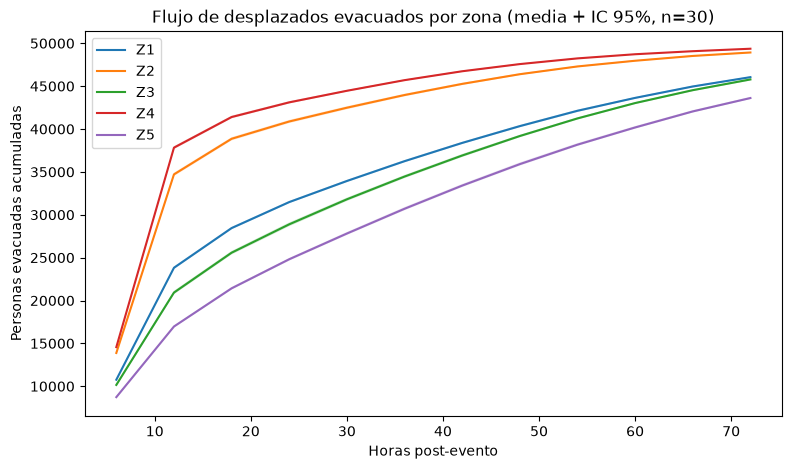

In [5]:
def bootstrap_ic95(muestras, B=2000, seed=0):
    """IC 95% no parametrico: remuestrea con reemplazo B veces sobre el
    eje de realizaciones (axis=0) y toma percentiles 2.5/97.5 de las medias
    remuestreadas. No asume normalidad de la variable de interes."""
    r = np.random.default_rng(seed)
    n = muestras.shape[0]
    media = muestras.mean(axis=0)
    remuestreos = np.empty((B,) + muestras.shape[1:])
    for b in range(B):
        idx = r.integers(0, n, size=n)
        remuestreos[b] = muestras[idx].mean(axis=0)
    lo = np.percentile(remuestreos, 2.5, axis=0)
    hi = np.percentile(remuestreos, 97.5, axis=0)
    return media, lo, hi


def correr_monte_carlo(campana_activa=False, n_real=m.N_REALIZACIONES, semilla_base=1000):
    trayectorias = []
    corridas = []
    for i in range(n_real):
        res = m.correr_realizacion(A, red, zona_de_agente, semilla=semilla_base + i,
                                    campana_activa=campana_activa)
        trayectorias.append(res["evacuados_por_zona_paso"])
        corridas.append(res)
    return np.array(trayectorias), corridas


def media_ic95(trayectorias):
    return bootstrap_ic95(trayectorias)


trayectorias_base, corridas_base = correr_monte_carlo(campana_activa=False)
media_base, lo_base, hi_base = media_ic95(trayectorias_base)

horas = np.arange(1, m.N_PASOS + 1) * 6
fig, ax = plt.subplots()
for z in range(m.N_ZONAS):
    ax.plot(horas, media_base[:, z], label=m.ZONAS[z])
    ax.fill_between(horas, lo_base[:, z], hi_base[:, z], alpha=0.2)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas evacuadas acumuladas")
ax.set_title("Flujo de desplazados evacuados por zona (media + IC 95%, n=30)")
ax.legend()
plt.show()


## 5. Outputs formales para Grupo 1 (Seccion 5 del Excel)

Grupo 6 debe entregar a Grupo 1: **(a)** proyeccion de flujo de desplazados
por zona y bloque, con destino; **(b)** estimacion de personas que NO podran
evacuar sin asistencia en Z1 y Z5 por bloque; **(c)** mapa de rutas
preferidas por comportamiento (no las optimas). Los tres se calculan a
continuacion y se exportan a `data/processed/`.

In [6]:
# (a) Proyeccion de flujo de desplazados por zona y momento, con destino
filas_a = []
flujo_destino_medio = np.array([r["flujo_destino_zona_paso"] for r in corridas_base]).mean(axis=0)
for t in range(m.N_PASOS):
    for z in range(m.N_ZONAS):
        filas_a.append({
            "bloque_tiempo": t + 1,
            "hora_post_evento": (t + 1) * 6,
            "zona_origen": m.ZONAS[z],
            "evacuados_acumulados_media": media_base[t, z],
            "ic95_inferior": lo_base[t, z],
            "ic95_superior": hi_base[t, z],
            "nuevos_hacia_refugio_oficial": flujo_destino_medio[t, z, 0],
            "nuevos_hacia_otra_zona": flujo_destino_medio[t, z, 1],
        })
df_a = pd.DataFrame(filas_a)
df_a.to_csv(OUTPUT_DIR / "output_a_flujo_desplazados.csv", index=False)
df_a.head(10)


,bloque_tiempo,hora_post_evento,zona_origen,evacuados_acumulados_media,ic95_inferior,ic95_superior,nuevos_hacia_refugio_oficial,nuevos_hacia_otra_zona
0,1,6,Z1,10762.500000,10619.979167,10923.354167,6347.500000,4415.000000
1,1,6,Z2,13883.333333,13719.145833,14064.166667,5898.333333,7985.000000
2,1,6,Z3,10156.666667,9979.145833,10338.354167,6908.333333,3248.333333
3,1,6,Z4,14565.000000,14402.500000,14739.187500,5114.166667,9450.833333
4,1,6,Z5,8731.666667,8579.145833,8862.500000,6805.000000,1926.666667
5,2,12,Z1,23818.333333,23670.791667,23977.500000,7565.833333,5490.000000
6,2,12,Z2,34710.000000,34506.625000,34906.687500,8838.333333,11988.333333
7,2,12,Z3,20926.666667,20720.833333,21139.187500,7425.000000,3345.000000
8,2,12,Z4,37826.666667,37649.937500,38001.687500,8203.333333,15058.333333
9,2,12,Z5,16967.500000,16835.000000,17095.041667,6453.333333,1782.500000


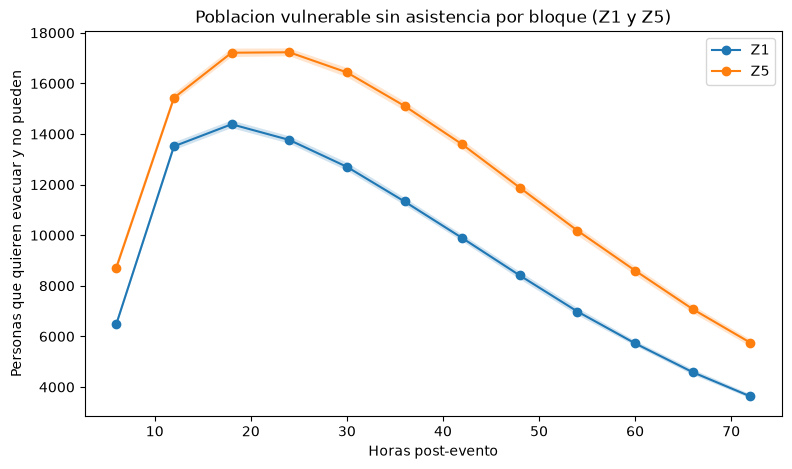

,zona,bloque_tiempo,hora_post_evento,personas_sin_poder_evacuar_media,ic95_inferior,ic95_superior
0,Z1,1,6,6485.833333,6356.645833,6605.000000
1,Z1,2,12,13514.166667,13360.833333,13666.687500
2,Z1,3,18,14385.833333,14231.666667,14535.020833
3,Z1,4,24,13766.666667,13620.000000,13915.041667
4,Z1,5,30,12703.333333,12550.812500,12871.687500
5,Z1,6,36,11332.500000,11190.000000,11479.187500
6,Z1,7,42,9889.166667,9756.645833,10025.020833
7,Z1,8,48,8407.500000,8260.000000,8555.000000
8,Z1,9,54,6982.500000,6840.000000,7125.854167
9,Z1,10,60,5725.000000,5626.666667,5829.166667


In [7]:
# (b) Personas que NO podran evacuar sin asistencia en Z1 y Z5, por bloque
def atrapados_por_bloque(corridas, zona_nombre):
    z = m.ZONAS.index(zona_nombre)
    conteos = []
    for res in corridas:
        mask_zona = res["zona_de_agente"] == z
        atrapado = res["quiere_pero_no_puede"][:, mask_zona].sum(axis=1) * m.FACTOR_ESCALA[z]
        conteos.append(atrapado)
    conteos = np.array(conteos)  # (n_real, n_pasos)
    return bootstrap_ic95(conteos)


filas_b = []
for zona_nombre in ("Z1", "Z5"):
    media_b, lo_b, hi_b = atrapados_por_bloque(corridas_base, zona_nombre)
    for t in range(m.N_PASOS):
        filas_b.append({
            "zona": zona_nombre, "bloque_tiempo": t + 1, "hora_post_evento": (t + 1) * 6,
            "personas_sin_poder_evacuar_media": media_b[t],
            "ic95_inferior": lo_b[t], "ic95_superior": hi_b[t],
        })
df_b = pd.DataFrame(filas_b)
df_b.to_csv(OUTPUT_DIR / "output_b_atrapados_sin_asistencia.csv", index=False)

fig, ax = plt.subplots()
for zona_nombre in ("Z1", "Z5"):
    sub = df_b[df_b["zona"] == zona_nombre]
    ax.plot(sub["hora_post_evento"], sub["personas_sin_poder_evacuar_media"], marker="o", label=zona_nombre)
    ax.fill_between(sub["hora_post_evento"], sub["ic95_inferior"], sub["ic95_superior"], alpha=0.2)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Personas que quieren evacuar y no pueden")
ax.set_title("Poblacion vulnerable sin asistencia por bloque (Z1 y Z5)")
ax.legend()
plt.show()
df_b.head(10)


In [8]:
# (c) Mapa de rutas preferidas por comportamiento (destino final acumulado por zona)
filas_c = []
for z in range(m.N_ZONAS):
    total_oficial = flujo_destino_medio[:, z, 0].sum()
    total_otra = flujo_destino_medio[:, z, 1].sum()
    total = total_oficial + total_otra
    filas_c.append({
        "zona": m.ZONAS[z],
        "pct_contacto_otra_zona_excel": m.REDES["pct_contacto_otra_zona"].iloc[z],
        "evacuados_hacia_refugio_oficial": total_oficial,
        "evacuados_hacia_otra_zona": total_otra,
        "pct_que_se_desvia_del_refugio_oficial": total_otra / total if total > 0 else 0.0,
    })
df_c = pd.DataFrame(filas_c).sort_values("pct_que_se_desvia_del_refugio_oficial", ascending=False)
df_c.to_csv(OUTPUT_DIR / "output_c_rutas_preferidas.csv", index=False)
df_c


,zona,pct_contacto_otra_zona_excel,evacuados_hacia_refugio_oficial,evacuados_hacia_otra_zona,pct_que_se_desvia_del_refugio_oficial
3,Z4,0.65,17330.833333,32032.500000,0.648913
1,Z2,0.58,20745.833333,28179.166667,0.575967
0,Z1,0.42,26756.666667,19292.500000,0.418954
2,Z3,0.31,31579.166667,14202.500000,0.310222
4,Z5,0.22,33998.333333,9614.166667,0.220445


## 6. Pregunta 1 (Analisis propio): autoevacuacion en Z1 y Z5, primeras 12h

Se mide la fraccion de la poblacion **no autonoma** (necesita_asistencia +
dependiente) de Z1 y Z5 que en algun momento de las primeras 12h (bloques 1
y 2) quiso evacuar pero no pudo por falta de asistencia a tiempo, y se
identifica el bloque con mayor efecto marginal de la asistencia.

In [9]:
def fraccion_atrapados_primeras_12h(corridas, zona_nombre):
    z = m.ZONAS.index(zona_nombre)
    fracciones = []
    for res in corridas:
        mask_zona = res["zona_de_agente"] == z
        no_autonomo = mask_zona & (res["tier"] != "autonomo")
        if no_autonomo.sum() == 0:
            continue
        atrapado_12h = res["quiere_pero_no_puede"][0:2, no_autonomo].any(axis=0)
        fracciones.append(atrapado_12h.mean())
    fracciones = np.array(fracciones)
    return bootstrap_ic95(fracciones)


for zona_nombre in ("Z1", "Z5"):
    media_f, lo_f, hi_f = fraccion_atrapados_primeras_12h(corridas_base, zona_nombre)
    print(f"{zona_nombre}: {100*media_f:.1f}% de la poblacion no autonoma "
          f"no pudo autoevacuar en las primeras 12h "
          f"(IC95%: [{100*lo_f:.1f}%, {100*hi_f:.1f}%])")


Z1: 70.6% de la poblacion no autonoma no pudo autoevacuar en las primeras 12h (IC95%: [70.1%, 71.0%])
Z5: 61.6% de la poblacion no autonoma no pudo autoevacuar en las primeras 12h (IC95%: [61.2%, 62.2%])


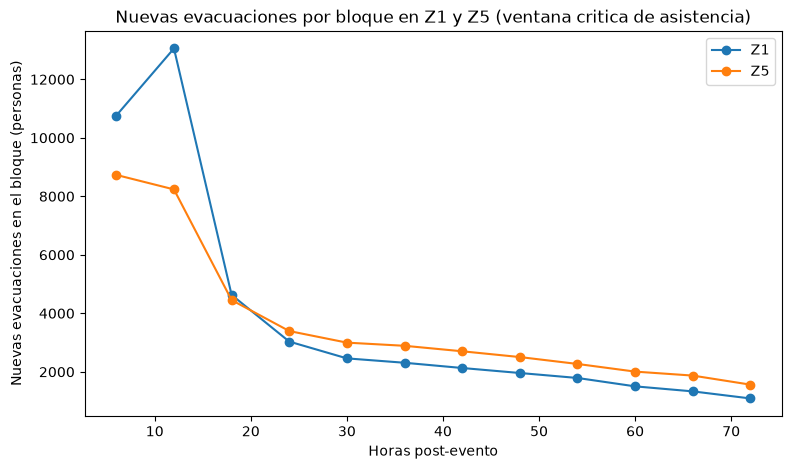

Z1: el bloque con mas nuevas evacuaciones (mayor efecto marginal de la asistencia) es el bloque 2 (horas 6-12).
Z5: el bloque con mas nuevas evacuaciones (mayor efecto marginal de la asistencia) es el bloque 1 (horas 0-6).


In [10]:
nuevos_medio_z1_z5 = np.array([r["nuevos_por_zona_paso"] for r in corridas_base]).mean(axis=0)
fig, ax = plt.subplots()
for z_nombre in ("Z1", "Z5"):
    z = m.ZONAS.index(z_nombre)
    ax.plot(horas, nuevos_medio_z1_z5[:, z], marker="o", label=z_nombre)
ax.set_xlabel("Horas post-evento")
ax.set_ylabel("Nuevas evacuaciones en el bloque (personas)")
ax.set_title("Nuevas evacuaciones por bloque en Z1 y Z5 (ventana critica de asistencia)")
ax.legend()
plt.show()

for z_nombre in ("Z1", "Z5"):
    z = m.ZONAS.index(z_nombre)
    paso_pico = int(np.argmax(nuevos_medio_z1_z5[:, z])) + 1
    print(f"{z_nombre}: el bloque con mas nuevas evacuaciones (mayor efecto marginal "
          f"de la asistencia) es el bloque {paso_pico} "
          f"(horas {(paso_pico-1)*6}-{paso_pico*6}).")


## 7. Pregunta 2 (Analisis propio): rutas modeladas vs. rutas optimas

**Ruta optima** (desde el punto de vista de infraestructura/planificacion):
todo evacuado de una zona deberia dirigirse al refugio oficial asignado a su
zona, para que la capacidad de cada refugio sea predecible.

**Ruta real segun el modelo:** una fraccion de los evacuados de cada zona,
proporcional a su `% con contactos en otra zona` (dato real del Excel, no
inventado), se dirige en cambio hacia otra zona, porque en una emergencia
la gente sigue a su red familiar y social, no la ruta oficialmente asignada.
Esto ya se calculo en la tabla `df_c` de la seccion 5.

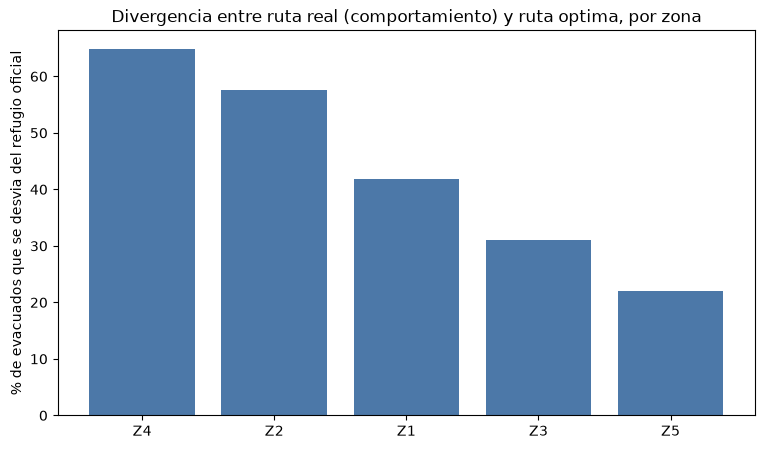

Mayor cuello de botella de planificacion: Z4 (65% de sus evacuados se dirige a otra zona en vez del refugio oficial asignado).


In [11]:
fig, ax = plt.subplots()
ax.bar(df_c["zona"], 100 * df_c["pct_que_se_desvia_del_refugio_oficial"], color="#4c78a8")
ax.set_ylabel("% de evacuados que se desvia del refugio oficial")
ax.set_title("Divergencia entre ruta real (comportamiento) y ruta optima, por zona")
plt.show()

peor = df_c.iloc[0]
print(f"Mayor cuello de botella de planificacion: {peor['zona']} "
      f"({100*peor['pct_que_se_desvia_del_refugio_oficial']:.0f}% de sus evacuados "
      f"se dirige a otra zona en vez del refugio oficial asignado).")


El mayor cuello de botella de evacuacion **no es de capacidad vial** (ese
dato pertenece a Grupo 4 y no fue recibido por Grupo 6 antes del
intercambio, por lo que no se inventa), sino de **planificacion de
refugios**: en las zonas con redes sociales mas extendidas fuera de su zona
(Z4: 65%, Z2: 58%, segun el Excel), una mayoria o cerca de la mitad de los
evacuados no llega al refugio oficial que la Municipalidad les asignaria,
sino que se dirige informalmente hacia otra zona. Z1 y Z5, con menor
conectividad externa (42% y 22%), se apegan mas a su refugio oficial pero
son las zonas mas lentas en iniciar la evacuacion (ver Pregunta 1). La
intervencion de comunicacion mas costo-efectiva es **anunciar explicitamente
que los refugios aceptan evacuados de cualquier zona y coordinar el
transporte de suministros en funcion del flujo real observado** (no del
flujo asumido por zona de residencia), en vez de intentar forzar a la
poblacion a seguir la ruta oficial contra su comportamiento real.

## 8. Pregunta 3 (Analisis propio): efecto de la desinformacion

Se comparan dos escenarios de 30 realizaciones cada uno, usando la
probabilidad real de informacion correcta por zona (Seccion 3 del Excel):
- **Base:** `prob_info_correcta` tal como esta en el Excel (p.ej. Z5: 0.48).
- **Campana oficial activa:** se reduce a la mitad la probabilidad de que
  circule un rumor, es decir `p_correcta_nueva = 1 - (1-p_correcta)/2`.

In [12]:
trayectorias_campana, corridas_campana = correr_monte_carlo(campana_activa=True, semilla_base=5000)
media_campana, lo_campana, hi_campana = media_ic95(trayectorias_campana)

print("Probabilidad de info correcta por zona, base vs. campana:")
comparacion_p = pd.DataFrame({
    "base": m.REDES["prob_info_correcta"].to_numpy(),
    "con_campana": m.prob_info_correcta_campana(True),
}, index=m.ZONAS)
display(comparacion_p)

bloque_48h = 7  # indice 0-based del paso 8 (48h)
diferencia = trayectorias_campana[:, bloque_48h, :] - trayectorias_base[:, bloque_48h, :]
media_dif, lo_dif, hi_dif = bootstrap_ic95(diferencia)

df_dif = pd.DataFrame({
    "zona": m.ZONAS,
    "personas_adicionales_evacuadas_48h": media_dif,
    "ic95_inferior": lo_dif,
    "ic95_superior": hi_dif,
}).sort_values("personas_adicionales_evacuadas_48h", ascending=False)
df_dif


Probabilidad de info correcta por zona, base vs. campana:


,base,con_campana
Z1,0.61,0.805
Z2,0.74,0.870
Z3,0.55,0.775
Z4,0.81,0.905
Z5,0.48,0.740


,zona,personas_adicionales_evacuadas_48h,ic95_inferior,ic95_superior
2,Z3,690.000000,500.000000,881.687500
0,Z1,579.166667,389.145833,770.875000
4,Z5,466.666667,229.166667,698.354167
1,Z2,130.000000,-16.687500,280.854167
3,Z4,-26.666667,-120.000000,63.333333


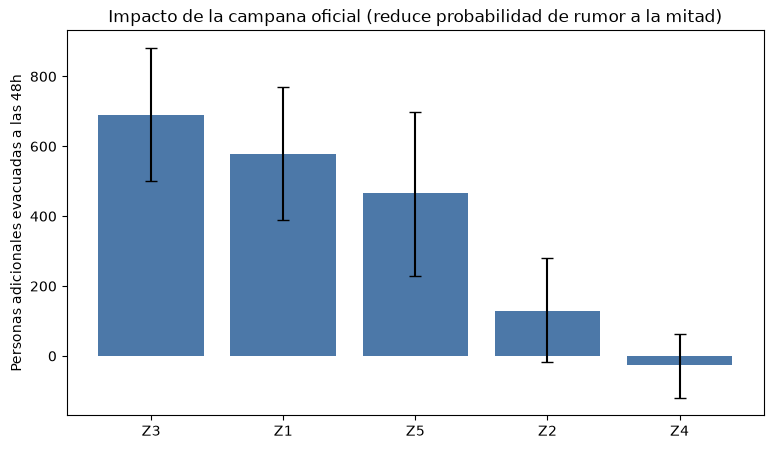

La zona donde la diferencia es mas significativa es Z3.


In [13]:
fig, ax = plt.subplots()
ax.bar(df_dif["zona"], df_dif["personas_adicionales_evacuadas_48h"],
       yerr=[df_dif["personas_adicionales_evacuadas_48h"] - df_dif["ic95_inferior"],
             df_dif["ic95_superior"] - df_dif["personas_adicionales_evacuadas_48h"]],
       capsize=4, color="#4c78a8")
ax.set_ylabel("Personas adicionales evacuadas a las 48h")
ax.set_title("Impacto de la campana oficial (reduce probabilidad de rumor a la mitad)")
plt.show()

zona_mas_impacto = df_dif.iloc[0]["zona"]
print(f"La zona donde la diferencia es mas significativa es {zona_mas_impacto}.")


## 8.1 Analisis de sensibilidad: incertidumbre de medicion en el Excel

La conclusion de la Pregunta 3 depende de `P_SIGUE_OFICIAL` (probabilidad
de seguir instrucciones oficiales en vez de un rumor): el Excel lo reporta
como un punto fijo, 0.54, pero es una estimacion de encuesta de
comportamiento y toda encuesta tiene margen de error de muestreo, no es un
valor exacto de la realidad, aunque el archivo lo entregue con un solo
decimal fijo. En vez de repetir la comparacion entre campana y base solo
con distinta semilla aleatoria del modelo (que ya se hizo en la seccion
anterior), aqui se repite variando el valor mismo de `P_SIGUE_OFICIAL`
entre 0.39 y 0.69 (un margen de error de muestreo plausible alrededor de
0.54), para ver si el patron de que zonas se benefician mas de la campana
se mantiene o depende criticamente del decimal exacto que dio el Excel.

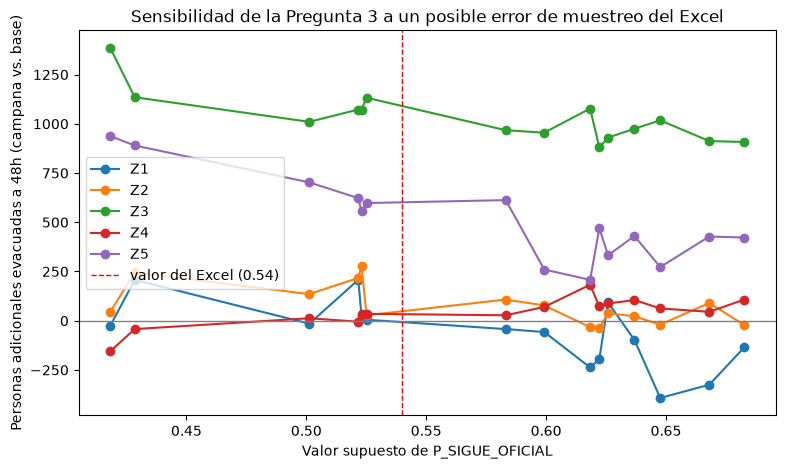

Zona mas beneficiada por la campana, segun cada valor muestreado de P_SIGUE_OFICIAL:
Z3    15
Name: count, dtype: int64


In [14]:
def diferencia_por_zona_bajo_confianza_oficial(valor_p_sigue_oficial, n_real=10, semilla_base=9000):
    original = m.P_SIGUE_OFICIAL
    m.P_SIGUE_OFICIAL = valor_p_sigue_oficial
    try:
        tb, _ = correr_monte_carlo(campana_activa=False, n_real=n_real, semilla_base=semilla_base)
        tc, _ = correr_monte_carlo(campana_activa=True, n_real=n_real, semilla_base=semilla_base + 500)
    finally:
        m.P_SIGUE_OFICIAL = original  # se restaura sin importar el resultado
    dif = tc[:, bloque_48h, :] - tb[:, bloque_48h, :]
    return dif.mean(axis=0)


rng_param = np.random.default_rng(42)
valores_confianza = np.sort(rng_param.uniform(0.39, 0.69, size=15))
resultados_sensibilidad = np.array([diferencia_por_zona_bajo_confianza_oficial(v) for v in valores_confianza])

df_sens = pd.DataFrame(resultados_sensibilidad, columns=m.ZONAS)
df_sens.insert(0, "p_sigue_oficial", valores_confianza)

fig, ax = plt.subplots()
for z_nombre in m.ZONAS:
    ax.plot(df_sens["p_sigue_oficial"], df_sens[z_nombre], "o-", label=z_nombre)
ax.axhline(0, color="gray", linewidth=1)
ax.axvline(0.54, color="red", linestyle="--", linewidth=1, label="valor del Excel (0.54)")
ax.set_xlabel("Valor supuesto de P_SIGUE_OFICIAL")
ax.set_ylabel("Personas adicionales evacuadas a 48h (campana vs. base)")
ax.set_title("Sensibilidad de la Pregunta 3 a un posible error de muestreo del Excel")
ax.legend()
plt.show()

zona_mas_beneficiada_por_muestra = df_sens[list(m.ZONAS)].idxmax(axis=1)
print("Zona mas beneficiada por la campana, segun cada valor muestreado de P_SIGUE_OFICIAL:")
print(zona_mas_beneficiada_por_muestra.value_counts())


## 9. Incorporacion del intercambio presencial

Segun la tabla de dependencias del examen, **Grupo 6 es proveedor puro**:
entrega la proyeccion de flujo de desplazados a Grupo 1 (outputs a, b, c de
la seccion 5), pero no figura como receptor formal de ningun otro grupo.
Las tres preguntas de Grupo 6 son de "Analisis propio", ninguna de
"Integracion del intercambio". *(Pendiente: confirmar con el catedratico el
dia del intercambio si aplica alguna entrega informal, por ejemplo el
desglose real de poblacion por zona, que este modelo tuvo que suponer
igualitario. Si se recibe, actualizar `POBLACION_ZONA` en
`src/grupo6_model.py` y volver a correr este notebook completo.)*

## 10. Limitaciones y propuestas de mejora

1. **Poblacion por zona asumida igualitaria (50,000 c/u):** el Excel de
   Grupo 6 no incluye este dato; con mas tiempo se solicitaria explicitamente
   al catedratico o se validaria contra el dato que sí maneja Grupo 1.
2. **Escala de agentes:** se simulan 2,000 agentes representativos por zona
   (10,000 en total) en vez de 250,000 habitantes reales, mediante un factor
   de escala. Se valido que el grado promedio de la red simulada coincide
   con el del Excel (seccion 3), pero no se valido que el factor de escala
   no distorsione la velocidad de propagacion a nivel poblacional completo.
3. **Capacidad de asistencia/rescate sin dato propio:** Grupo 6 no recibe el
   plan de despliegue de Grupo 5, asi que `prob_asistencia()` es una funcion
   generica calibrada solo con el `indice_riesgo_rezago` propio de cada
   zona. Si se recibiera el dato real de Grupo 5, se reemplazaria esa
   funcion directamente.
4. **Ruta optima simplificada:** se compara contra "ir siempre al refugio
   oficial de la zona", no contra una ruta optimizada por capacidad vial
   real (ese dato es de Grupo 4 y no llega a Grupo 6 formalmente). Si en el
   intercambio se recibiera informalmente, se podria refinar el analisis de
   la Pregunta 2 con capacidades reales de las vias.
5. **Actualizacion sincrona por bloque:** dentro de cada bloque de 6h todas
   las decisiones se calculan a partir del mismo estado inicial del bloque,
   sin orden de activacion entre agentes. Esto es razonable a la escala de
   6h que impone el Excel, pero si se quisiera capturar el orden exacto en
   que las decisiones se propagan dentro de una misma ventana de horas
   (p. ej. quien se entera primero dentro del mismo bloque), haria falta
   una resolucion temporal mas fina con activacion secuencial, lo cual
   multiplicaria el costo computacional.